# 딥러닝 3일차

In [22]:
import keras 
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [23]:
# 실행할 때마다 랜덤 값이 동일하게 나오고 싶으면, seed 지정할 것
keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

In [24]:
# 데이터 불러오기(학습만)
(train_input, train_target), _ = keras.datasets.fashion_mnist.load_data()
train_scale = train_input / 255.0

In [25]:
# 데이터 분할
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scale, train_target, test_size=0.2)

In [26]:
train_scaled.shape, val_scaled.shape

((48000, 28, 28), (12000, 28, 28))

In [27]:
# 모델 생성 함수
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28, 28)))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(100, activation='relu')) # 은닉층
    if a_layer:
        model.add(a_layer) # 매개변수가 있는 경우
    model.add(keras.layers.Dense(10, activation='softmax')) # 출력층
    return model

In [28]:
model = model_fn()
model.compile(loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.SparseCategoricalAccuracy()])
history = model.fit(train_scaled, train_target, epochs=5) 

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5311 - sparse_categorical_accuracy: 0.8112
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3906 - sparse_categorical_accuracy: 0.8586
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3533 - sparse_categorical_accuracy: 0.8728
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3294 - sparse_categorical_accuracy: 0.8809
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3129 - sparse_categorical_accuracy: 0.8888


In [29]:
history.history['loss']

[0.5311373472213745,
 0.3905622661113739,
 0.35328060388565063,
 0.3294256031513214,
 0.31286561489105225]

Text(0.5, 1.0, 'train loss')

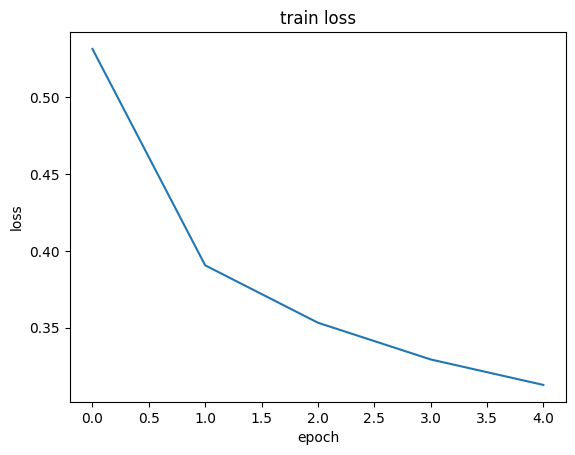

In [30]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('train loss')

In [31]:
model = model_fn()
model.compile(loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.SparseCategoricalAccuracy()])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0) # epoch 20, 출력 없이 

Text(0.5, 1.0, 'train loss')

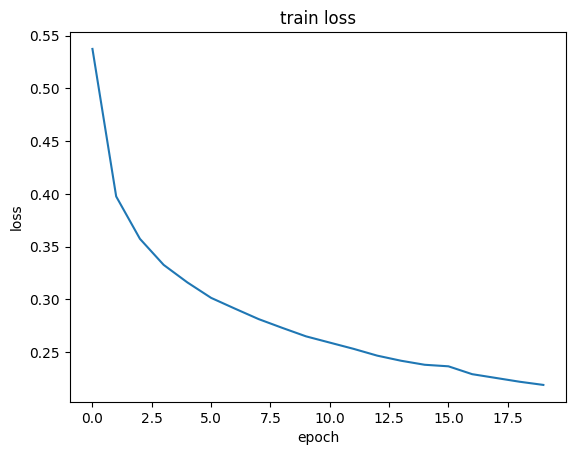

In [32]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('train loss')

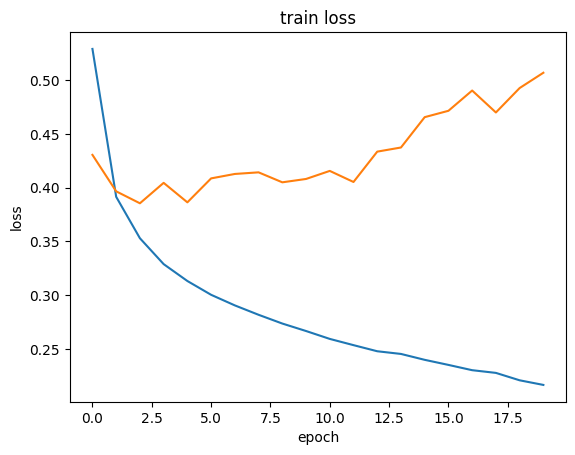

In [ ]:
# validation 검증 데이터와 손실(loss) 비교
model = model_fn()
# optimizer : rmsprop
model.compile(loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.SparseCategoricalAccuracy()])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0, # epoch 20, 출력 없이 
                    validation_data=(val_scaled, val_target)
                    ) 

import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('train loss and val loss')
plt.show()

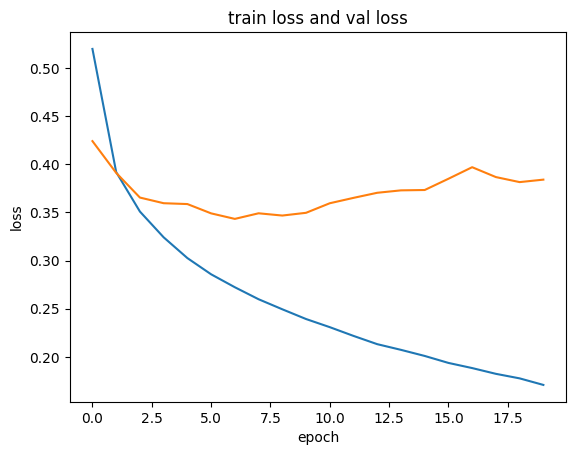

In [36]:
# validation 검증 데이터와 손실(loss) 비교
model = model_fn()
# optimizer : adam
model.compile(optimizer='adam',
    loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.SparseCategoricalAccuracy()],
              )
history = model.fit(train_scaled, train_target, epochs=20, verbose=0, # epoch 20, 출력 없이 
                    validation_data=(val_scaled, val_target)
                    ) 

import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('train loss and val loss')
plt.show()

# DropOut

In [37]:
model = model_fn(a_layer=keras.layers.Dropout(0.3)) # 드롭 아웃 층을 추가

# model.compile(optimizer='adam',
#     loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.SparseCategoricalAccuracy()],
#               )
# history = model.fit(train_scaled, train_target, epochs=20, verbose=0, # epoch 20, 출력 없이 
#                     validation_data=(val_scaled, val_target)
#                     ) 



In [ ]:
model.summary() # 파라미터 수는 변화없음
# 뉴런을 끄는 연산만 하고, 가중치는 그대로여서, 파라미터 수는 변함없다

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

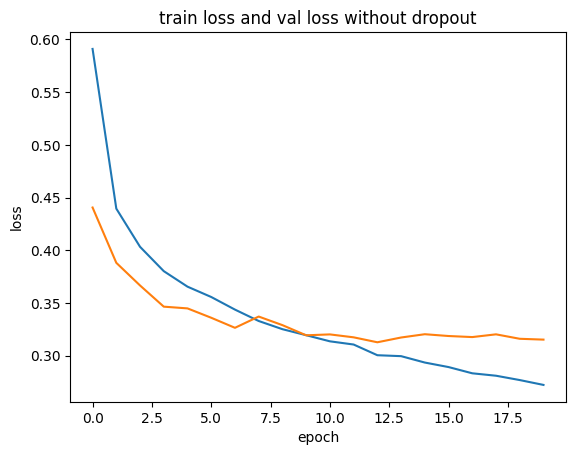

In [39]:
model.compile(optimizer='adam',
    loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.SparseCategoricalAccuracy()],
              )
history = model.fit(train_scaled, train_target, epochs=20, verbose=0, # epoch 20, 출력 없이 
                    validation_data=(val_scaled, val_target)
                    ) 

import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('train loss and val loss without dropout')
plt.show()

In [40]:
history.history['loss']

[0.5910605788230896,
 0.4395841360092163,
 0.40335649251937866,
 0.3802718222141266,
 0.36555951833724976,
 0.3557487428188324,
 0.34379512071609497,
 0.3329840898513794,
 0.32522618770599365,
 0.3195129930973053,
 0.3137114644050598,
 0.3106714189052582,
 0.3005266785621643,
 0.299642413854599,
 0.2935797870159149,
 0.2892906963825226,
 0.28337493538856506,
 0.28107768297195435,
 0.27696406841278076,
 0.2723550498485565]

In [ ]:
# 드롭아웃 외에도 정규화 방법들이 존재
# L2 정규화 : 수학적 해석 명확, 소규모 데이터셋에서 안정적으로 작동, 랜덤 요소 없음
# model.add(keras.layers.Dense(100, activation='relu', kernel_regularizer='12'))

# Dropout : 컴퓨터비전(CV)에서 표준.

# 모델 저장

In [42]:
model.save('model.keras') # 모델의 구조와 가중치를 모두 저장

In [43]:
# 가중치만 저장
model.save_weights('model.weights.h5') # HDF5 포맷으로 저장

In [44]:
model2 = model_fn(keras.layers.Dropout(0.3))
model2.load_weights('model.weights.h5') # 같은 구조의 모델은 가중치만 불러오기 가능

In [45]:
# compile, fit 없어도 바로 예측 가능
model2.predict(val_scaled)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step


array([[1.2214554e-14, 1.1805704e-20, 1.8217738e-17, ..., 1.2980674e-13,
        9.9999988e-01, 8.1253602e-22],
       [1.4518136e-09, 4.8329318e-18, 1.0536618e-10, ..., 1.0037579e-13,
        1.0000000e+00, 1.2755261e-15],
       [6.5088066e-15, 1.3958384e-14, 8.6913214e-16, ..., 9.9995279e-01,
        6.0372147e-09, 1.8416102e-07],
       ...,
       [9.2909545e-07, 2.1692534e-14, 6.6742980e-09, ..., 1.7267356e-08,
        9.9999511e-01, 3.8488510e-09],
       [1.0077519e-13, 2.2050220e-22, 7.4119189e-16, ..., 1.3370183e-18,
        1.0000000e+00, 1.9849843e-24],
       [2.0824404e-02, 7.6830133e-08, 7.9126206e-05, ..., 1.5579470e-02,
        1.5524902e-06, 9.4424272e-01]], shape=(12000, 10), dtype=float32)

In [ ]:
model3 = keras.models.load_model('model.keras')
model3.evaluate(val_scaled, val_target) # 바로 확인 가능 loss, accuracy

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - loss: 0.3153 - sparse_categorical_accuracy: 0.8850


[0.3153291642665863, 0.8849999904632568]

## CallBack
- 학습(fit) 실행 중, 특정 이벤트에 자동으로 동작하는 함수.

In [48]:
checkpoint = keras.callbacks.ModelCheckpoint('best-model.keras', save_best_only=True) # 최적은 val_loss 개선될 때만 저장

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5900 - sparse_categorical_accuracy: 0.7910 - val_loss: 0.4310 - val_sparse_categorical_accuracy: 0.8445
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4360 - sparse_categorical_accuracy: 0.8424 - val_loss: 0.3766 - val_sparse_categorical_accuracy: 0.8632
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4034 - sparse_categorical_accuracy: 0.8548 - val_loss: 0.3609 - val_sparse_categorical_accuracy: 0.8676
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3816 - sparse_categorical_accuracy: 0.8616 - val_loss: 0.3546 - val_sparse_categorical_accuracy: 0.8684
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3643 - sparse_categorical_accuracy: 0.8657 - val_loss: 0.3393 - val_sparse_categorical_accuracy: 0.8746
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3525 - sparse_categorical_accuracy: 0.8709 - val_loss: 0.3376 - val_sparse_categorical_accuracy:

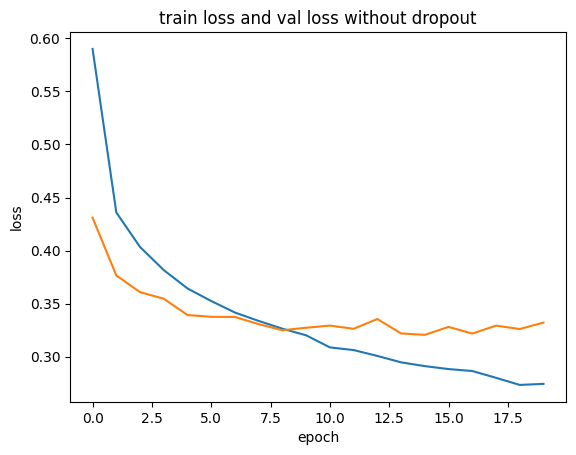

In [49]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam',
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
              )
history = model.fit(train_scaled, train_target, epochs=20, verbose=1, # epoch 20, 출력 없이 
                    validation_data=(val_scaled, val_target),
                    callbacks= [checkpoint] # 콜백함수 추가
                    ) 

import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('train loss and val loss without dropout')
plt.show()

In [50]:
# 최적의 모델 불러오기
model_best = keras.models.load_model('best-model.keras')


In [51]:
model_best.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - loss: 0.3206 - sparse_categorical_accuracy: 0.8840


[0.3205919563770294, 0.8840000033378601]

# 조기종료

In [52]:
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss',  # val_loss 모니터링하다가
                              patience=2, # 2에폭보다 개선 없으면
                              restore_best_weights=True) # 가장 좋았던 때로 복원